# Regular Expressions 

In [ ]:
import pandas as pd 
import re 

## 1. Basic String Operations in Pandas

In [ ]:
# You have a Pandas Series with messy strings: 

data = pd.DataFrame({
    'FirstName': ["  Alice ", "BOB", "ChArLiE ", " daVe ", "eve    "], 
    'LastName': ["Brown", "Smith", "Jones", "Davis", "Wilson"]
})

data 

In [ ]:
# Remove any leading or trailing spaces from the 'FirstName'. 
# Convert all names to lowercase. 
# Convert all names to title case (first letter capitalized). 

data['FirstName'] = data['FirstName'].str.strip() 
data['FirstName'] = data['FirstName'].str.lower() 
data['FirstName'] = data['FirstName'].apply(lambda x: x[0].upper() + x[1:]) 

# Alternatively: data['FirstName'] = data['FirstName'].str.title() 

data 

In [ ]:
# Create a new column 'Full Name' by joining the first and the last name, spaced 

data['Full Name'] = data['FirstName'] + ' ' + data['LastName'] 
data 

In [ ]:
# Filter out all the rows where the names start with 'A' 

# note that the output is a boolean Series, where True represents a match with the condition given 
data['Full Name'].str.startswith('A') 

In [ ]:
# note that without explicitly converting to 'str' (missing the '.str' command), the code fails 

data['Full Name'].startswith('A') 

In [ ]:
# upon passing the given boolean Series to the dataframe, the rows where the condition is true are filtered and returned 

data[data['Full Name'].str.startswith('A')] 

In [ ]:
# Filter out all the rows where the names end with 'th' or 'n' 

data[(data['Full Name'].str.endswith('th')) | (data['Full Name'].str.endswith('n'))] 

In [ ]:
# Filter out all the rows where the names contain the substring 've' 

data[data['Full Name'].str.contains('ve')] 

## 2. Extracting Information Using Regex

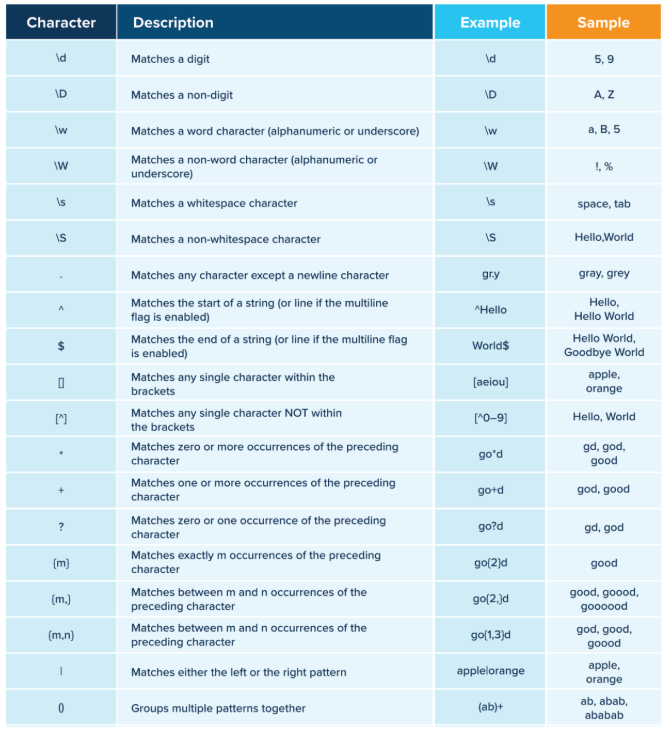

In [ ]:
# You are given the following Pandas Series: 

emails = pd.Series([
    "Contact us at support@xyz.com",
    "Email me at hello123@gmail.com",
    "Reach out: info@company.org",
    "No email here!"
]) 
emails 

In [ ]:
# Extract only the email addresses using regex.
# Replace all domain names (e.g., @xyz.com, @gmail.com) with @example.com.

exp = r'(@[A-Za-z0-9\.]+[a-z]{2,})'
emails.str.replace(exp, '@example.com', regex=True) 

In [ ]:
# Given the following text data:

dates = pd.DataFrame({
    'date': [
    "12/05/2023",
    "24/01/2015",
    "03/12/1995",
    "08/01/2025"
]}) 

dates 

In [ ]:
# Extract year from the given dates 

dates['date'].str.split('/')   # returns a list of substrings separated by '/' 

In [ ]:
dates['date'].str.split('/').str[2]    # returns the year (at the 3rd index of each date array) 

## 3. RegEx Challenges 

In [ ]:
# (a) Validating Passwords

# A valid password must:
#     Have at least one uppercase letter.
#     Have at least one lowercase letter.
#     Have at least one number.
#     Be at least 8 characters long.

# Write a function to validate a Pandas Series of passwords. 

passwords = pd.Series(["Hello123", "weakpass", "Str0ngPass!", "12345678"]) 
passwords 

In [ ]:
password_pattern = r"^(?=.*[a-z])(?=.*[A-Z])(?=.*\d).{8,}" 
passwords.str.match(password_pattern) 

In [ ]:
# (b) You are analyzing Twitter data 

# Extract all hashtags (#word). 
# Extract all mentions (@user). 

tweets = pd.Series([
    "Loving the weather today! #sunny #happy",
    "Big news! @elonmusk just announced something huge. #technology",
    "No hashtags or mentions here!",
    "@user1 and @user2 are having a great conversation. #chat"
]) 

tweets 

In [ ]:
hash_exp = r'(#[A-Za-z0-9_!]+)' 
tweets.str.findall(hash_exp) 

In [ ]:
mentions_exp = r'(@[A-Za-z0-9_]+)' 
tweets.str.findall(mentions_exp)

In [ ]:
# (c) You have web server logs 

# Extract all IP addresses. 
# Extract the date from each log entry. 

logs = pd.DataFrame({
    'logs': [
    "192.168.1.1 - - [10/Feb/2024:14:23:31 +0000] GET /index.html 200",
    "10.0.0.5 - - [12/Mar/2023:10:10:10 +0000] GET /home 404",
    "172.16.0.3 - - [01/Jan/2022:22:45:00 +0000] POST /login 500"
]}) 

logs 

In [ ]:
# Extract all IP addresses. 

ip_exp = r'([0-9]{1,3}\.[0-9]{1,3}\.[0-9]{1,3}\.[0-9]{1,3})'   # ___.___.___.___ 
logs['IP Address'] = logs['logs'].str.extract(ip_exp) 
logs 

In [ ]:
# Extract the date from each log entry. 

# day (2-digit format) / month (3-character format) / year (4 digit format) 
date_exp = r'([0-9]{2}/[A-Z][a-z]{2}/[0-9]{4})' 
logs['Date'] = logs['logs'].str.extract(date_exp) 
logs 

In [ ]:
# (d) Identifying Suspicious Activity 

# Find log entries where the response code is 500 (server error). 

logs[logs['logs'].str.split(' ').str[-1] == '500'] 

In [ ]:
# (e) Write a regex pattern that matches words containing a consecutive even number of vowels. 

word_list = pd.Series(["meet", "noon", "banana", "apple", "hello", 'dad'])

word_list.str.contains(r'([aeiou]{2})+', even_vowel_pattern)

In [ ]:
# This regex looks for at least two vowels separated by any number of consonants.
# NOTE: This is technically 'advanced regex' and out of the scope of this course.
# It uses a "non-capturing group" (?:) to group the vowel-finding logic 
# and repeats it 2 or more times {2,} to find words with multiple vowels.

even_vowel_pattern = r"^(?:[^aeiou]*[aeiou][^aeiou]*){2,}" 
word_list.str.match(even_vowel_pattern) 

## Practice Problem 

In [ ]:
# reading data 

df = pd.read_csv('/kaggle/input/datasets/shizzaasherfastnulhr/cs-334-datasets/Economy_of_US.csv') 
df.head() 

In [ ]:
# Q) Write a function that cleans the "Inflation_Change" column of your dataset. The function should:
# Replace all missing values with 'unknown'. 
# Replace all non-alphabetical characters with empty strings.
# Convert the cleaned values to lowercase.
# Apply this function to the "Inflation_Change" column of the DataFrame.

def clean_inflation_change(text): 
    if pd.isna(text): 
        return 'unknown' 
    pattern = r'(^[A-Za-z])' 
    re.sub(pattern, '', text) 
    text.lower() 
    return text 

df['Inflation_Change'] = df['Inflation_Change'].apply(clean_inflation_change) 
df 